# DTLZ3 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 1000
NGEN = 600
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz3_segura = partial(benchmarks.dtlz3, obj=NOBJ)
toolbox = build_toolbox(func_dtlz3_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 160
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[0.9999999999783562, 0.9999999793908704, 0.0, 0.0, 0.5000000917957611, 0.5000015466247286, 0.49977173867161656, 0.4999994885834883, 0.49999801481020284, 0.4999999095654424, 0.4999999042530162, 0.4999999002843698, 0.5000010869570511, 0.49999973411312076]
[0.0, 0.0, 0.0, 1.027351673303671e-05, 0.5000000117902721, 0.5000002181562189, 0.5000000690176918, 0.49999986691078563, 0.49999868029132066, 0.5000426976335697, 0.49999991454301335, 0.49999993625655165, 0.5000011744709891, 0.49999978069747614]
[0.9999999970045677, 0.0, 0.0, 0.0, 0.5000001219677104, 0.5000000224129504, 0.49999979934852073, 0.5000000628407694, 0.49999866684993804, 0.4999999165103965, 0.4999999506279151, 0.4999999543321998, 0.5000011419260395, 0.4999997845912772]
[0.9999999999999976, 1.0, 0.999999999999997, 0.0, 0.5000001248338777, 0.50000036224462, 0.500000075813619, 0.500000071936574, 0.49999871565776516, 0.5773430429470396, 0.5001911106277862, 0.49999994184172436, 0.49993032039159563, 0.4999998060389524]
[1.0, 1.0, 1.0,

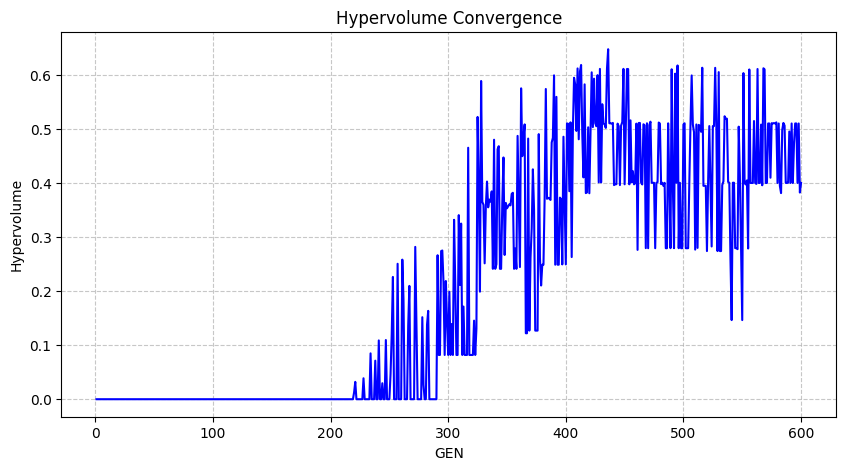

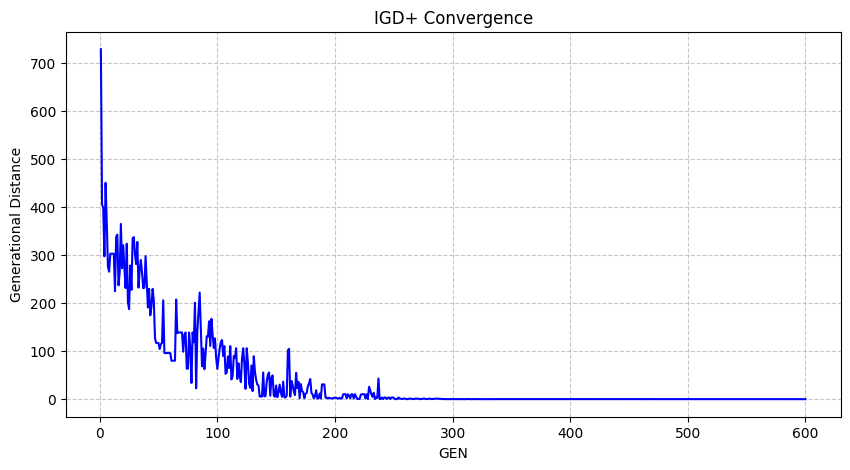

In [8]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()